# Тема 5. Ансамблевые методы и случайный лес

## Практика: случайный лес против дерева на «Титанике»

В теме 3 дерево решений дало accuracy ≈0.80 на valid. Проверим, насколько лес лучше — и заодно посмотрим на OOB-оценку в деле.

Самостоятельная работа. Если не хватает метода — см. `lesson05_ensembles_theory.ipynb`.

**Это файл с решениями — используйте для самопроверки.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

%config InlineBackend.figure_format = 'svg'
RANDOM_STATE = 42

**1. Подготовка данных** — та же, что в темах 3-4.

In [2]:
data = pd.read_csv("../data/titanic_train.csv", index_col="PassengerId")
data["Sex"] = (data["Sex"] == "male").astype(int)
data["Age"] = data["Age"].fillna(data["Age"].median())

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = data[features]
y = data["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

**2. Обучите `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)`. Какая accuracy на valid — лучше дерева из темы 3 (≈0.80)?**

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
round(rf.score(X_valid, y_valid), 4)

0.8097

**3. Сколько деревьев на самом деле нужно?** Для `n_estimators` из `[5, 10, 25, 50, 100, 200, 400]` обучите лес и запишите accuracy на valid. Постройте график: ось X — `n_estimators`, ось Y — accuracy.

С какого момента рост числа деревьев перестаёт заметно помогать?

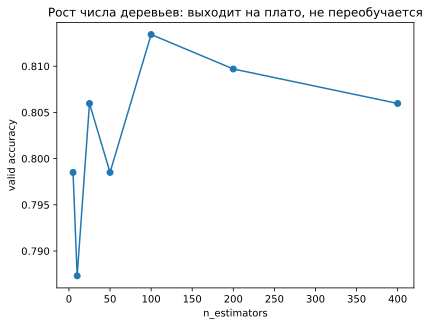

In [4]:
n_values = [5, 10, 25, 50, 100, 200, 400]
scores = []
for n in n_values:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf_n.fit(X_train, y_train)
    scores.append(rf_n.score(X_valid, y_valid))

plt.plot(n_values, scores, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("valid accuracy")
plt.title("Рост числа деревьев: выходит на плато, не переобучается");

**4. Обучите лес на *всех* данных (`X`, `y`) с `oob_score=True`. Сравните `oob_score_` с `cross_val_score(..., cv=5).mean()` на том же лесе. Совпадают?**

In [5]:
rf_oob = RandomForestClassifier(
    n_estimators=200, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1
)
rf_oob.fit(X, y)

cv_score = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), X, y, cv=5
).mean()

print("OOB:", round(rf_oob.oob_score_, 4))
print("CV: ", round(cv_score, 4))

OOB: 0.8193
CV:  0.8137


**5. Постройте `feature_importances_` леса в виде `barh`. Какой признак важнее всего — совпадает с деревом из темы 3 (там был `Sex`)?**

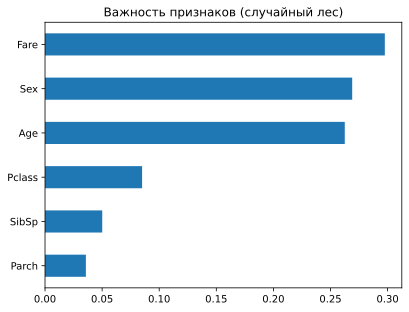

In [6]:
pd.Series(rf_oob.feature_importances_, index=features).sort_values().plot(
    kind="barh", title="Важность признаков (случайный лес)"
);

**6 (бонус). Обучите лес с `max_features=1` (каждое дерево видит только 1 случайный признак на узел — почти максимальная декорреляция) и с `max_features=6` (все признаки — почти как бэггинг без "случайности леса"). Что с accuracy?**

In [7]:
for mf in [1, 3, "sqrt", 6]:
    rf_mf = RandomForestClassifier(
        n_estimators=200, max_features=mf, random_state=RANDOM_STATE, n_jobs=-1
    )
    rf_mf.fit(X_train, y_train)
    print(f"max_features={mf}: {rf_mf.score(X_valid, y_valid):.4f}")

max_features=1: 0.8022


max_features=3: 0.8097


max_features=sqrt: 0.8097


max_features=6: 0.8097


---
## Итог

Лес заметно стабильнее дерева и обычно точнее. Следующее занятие — конструирование признаков: посмотрим, можно ли увеличить точность не сменой модели, а более умными признаками.